# Validating binary orbits against their birth particles

This script will validate the orbtis of binaries seeded into the orbital framework developed for Auriga galaxies. Provided that the evolved binaries have not yet received their kick velocities, the orbits should trace the evolution of the particles.

In theory, if the semi-analytical potentials have been constructed properly, the binary should follow the particle with a small degree of uncertainty. However, given that the snapshot intervals are discrete, it's possible for some binaries to deviate wildly due to interactions that are not encapsulated in the time frame.


## Loading in modules

In [1]:
!python -m pip install --user numpy
!python -m pip install --user pandas
!python -m pip install --user matplotlib
!python -m pip install --user scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.path as mpath
import matplotlib.animation as animation
from scipy.spatial.transform import Rotation as R

In [2]:
"Functions"
def unit_axis_angle(a, b):
    an = np.sqrt(a[0]*a[0] + a[1]*a[1] + a[2]*a[2]) #Normalisation factor
    bn = np.sqrt(b[0]*b[0] + b[1]*b[1] + b[2]*b[2])
    ax, ay, az = a[0]/an, a[1]/an, a[2]/an #Normalise
    bx, by, bz = b[0]/bn, b[1]/bn, b[2]/bn #Normalise
    nx, ny, nz = ay*bz-az*by, az*bx-ax*bz, ax*by-ay*bx #Cross product AxB
    nn = np.sqrt(nx*nx + ny*ny + nz*nz) #Normal vector normalisation factor
    return (nx/nn, ny/nn, nz/nn), np.arccos(ax*bx + ay*by + az*bz) #unit normalisation

def rotation_matrix(axis, angle):
	#angle in rads
    ax, ay, az = axis[0], axis[1], axis[2] #Normal axis
    s = np.sin(angle)
    c = np.cos(angle)
    u = 1 - c
    return ( ( ax*ax*u + c,    ax*ay*u - az*s, ax*az*u + ay*s ),
             ( ay*ax*u + az*s, ay*ay*u + c,    ay*az*u - ax*s ),
             ( az*ax*u - ay*s, az*ay*u + ax*s, az*az*u + c    ) )



In [3]:
def euler_to_spherical(angles):
	polar = np.arctan2(angles[1],angles[0])
	azi = np.arccos(angles[2]/np.linalg.norm(angles))
	return polar,azi

#euler_to_spherical(np.radians([14.14663318,3.13256624,-81.5353491]))

## Loading in files

In [ ]:
import os


initial_snapshot= 99
latest_snapshot = 127
kick_suff= ""#"nokick" #nokick or ""
filename = "..\\orbit_ready\\sep_test_orbits_sampled_nokick_growpot_df_smbh__{}_{}_beta_1000_batch_0_hr.0.h5".format(initial_snapshot,latest_snapshot)
filename = ".\\orbit_ready_redone_v8\sep_VIC17_test_orbits_sampled_growpot_df_smbh_{}_{}_{}_beta_100_batch_0_hr.0.h5".format(kick_suff,initial_snapshot,latest_snapshot)
print(filename,os.path.isfile(filename))
if os.path.isfile(filename) == False:
    raise ValueError("File Does Not Exist")
else:
    print("Found file...\n")

store = pd.HDFStore(filename,"r")

print(store.keys())

.\orbit_ready_redone_v6\sep_VIC17_test_orbits_sampled_growpot_df_smbh__79_127_beta_100_batch_0_hr.0.h5 True
Found file...

['/bin_fract', '/bin_overview', '/ref', '/snap_overview', '/track_parts', '/run_orbit/100', '/run_orbit/101', '/run_orbit/102', '/run_orbit/103', '/run_orbit/104', '/run_orbit/105', '/run_orbit/106', '/run_orbit/107', '/run_orbit/108', '/run_orbit/109', '/run_orbit/110', '/run_orbit/111', '/run_orbit/112', '/run_orbit/113', '/run_orbit/114', '/run_orbit/115', '/run_orbit/116', '/run_orbit/117', '/run_orbit/118', '/run_orbit/119', '/run_orbit/120', '/run_orbit/121', '/run_orbit/122', '/run_orbit/123', '/run_orbit/124', '/run_orbit/125', '/run_orbit/126', '/run_orbit/127', '/run_orbit/79', '/run_orbit/80', '/run_orbit/81', '/run_orbit/82', '/run_orbit/83', '/run_orbit/84', '/run_orbit/85', '/run_orbit/86', '/run_orbit/87', '/run_orbit/88', '/run_orbit/89', '/run_orbit/90', '/run_orbit/91', '/run_orbit/92', '/run_orbit/93', '/run_orbit/94', '/run_orbit/95', '/run_orbi

In [5]:

"Particle orbit histories"
print(store.keys())
part_track = store.track_parts #Particle tracker
ref = store.ref #Reference table
print(ref.head()) #Overview of the table values and columns

['/bin_fract', '/bin_overview', '/ref', '/snap_overview', '/track_parts', '/run_orbit/100', '/run_orbit/101', '/run_orbit/102', '/run_orbit/103', '/run_orbit/104', '/run_orbit/105', '/run_orbit/106', '/run_orbit/107', '/run_orbit/108', '/run_orbit/109', '/run_orbit/110', '/run_orbit/111', '/run_orbit/112', '/run_orbit/113', '/run_orbit/114', '/run_orbit/115', '/run_orbit/116', '/run_orbit/117', '/run_orbit/118', '/run_orbit/119', '/run_orbit/120', '/run_orbit/121', '/run_orbit/122', '/run_orbit/123', '/run_orbit/124', '/run_orbit/125', '/run_orbit/126', '/run_orbit/127', '/run_orbit/79', '/run_orbit/80', '/run_orbit/81', '/run_orbit/82', '/run_orbit/83', '/run_orbit/84', '/run_orbit/85', '/run_orbit/86', '/run_orbit/87', '/run_orbit/88', '/run_orbit/89', '/run_orbit/90', '/run_orbit/91', '/run_orbit/92', '/run_orbit/93', '/run_orbit/94', '/run_orbit/95', '/run_orbit/96', '/run_orbit/97', '/run_orbit/98', '/run_orbit/99', '/init_orbit/79']
                           ID             Binar

## Function to cross match particles and binaries

In [6]:
def load_next_particle():
	#print(len(part_list),len(store.ref.Particle_ID)) #Particle length
	for i, p in enumerate(part_list):
		print("[{}] Current particle: {}, Binary: {}".format(i,p,bin_list.iloc[i]))
		yield i


def extract_orbit(ss,binary,ss_init=1,ss_max=128):
	tab_name = "/run_orbit/{}".format(ss)
	if tab_name in store.keys():
		#print("Key found")
		_temp_tab = store[tab_name]
		_temp_tab = _temp_tab.drop_duplicates(keep='first')
		_temp_tab = _temp_tab.merge(ref_cut[["ID"]],how='inner', left_on="ID",right_on="ID")
		cond = np.where(np.asarray(_temp_tab["ID"].values).astype(str) == str(binary))
		sel_tab = _temp_tab.iloc[cond] #Selected table with binary value
		#print(sel_tab)
		return sel_tab
	else:
		return



In [7]:
"Choose a particle"

ref_cut = ref.drop_duplicates(subset='Particle_ID',keep='first')
apply_refcut = False#False #If true will filter out particles
if apply_refcut:
		data = store["run_orbit/{}".format(latest_snapshot)]
		data.drop_duplicates("ID",keep="last")
		r = np.sqrt(data.x.astype(float)**2+data.y.astype(float)**2+data.z.astype(float)**2)
		#cond = np.where(r > 100) #cut
		cond = np.where(r < 20)

		data = data.iloc[cond]
		IDs = data["ID"]
		ref_cut = ref_cut.merge(data[["ID"]],left_on='ID',right_on='ID')

bin_list = ref_cut["ID"]
part_list = ref_cut["Particle_ID"]
p_loader= load_next_particle()
#print(store["bin_overview"].columns)
joint_tab = ref_cut.merge(store["bin_overview"][["Unique_ID","Age 1 [yr]","Kick 1 [km/s]","Age 2 [yr]","Kick 2 [km/s]"]]
                          ,how="inner",left_on = "Binary_ID",right_on = "Unique_ID")
print(joint_tab)

                             ID             Binary_ID    Particle_ID  \
0    9480S88303978830397Z0006N0  S88303978830397Z0006  8796510079480   
1    8551S56328145632814Z0006N0  S56328145632814Z0006  8796503068551   
2    3430S81010048101004Z0006N0  S81010048101004Z0006  8796485463430   
3    1114S87513168751316Z0006N0  S87513168751316Z0006  8796494071114   
4    2338S95712699571269Z0008N0  S95712699571269Z0008  8796505922338   
..                          ...                   ...            ...   
819     3906S670774670774Z004N0     S670774670774Z004  8796482133906   
820   9783S16590941659094Z004N0   S16590941659094Z004  8796501079783   
821   0583S15860061586006Z004N0   S15860061586006Z004  8796498040583   
822   7788S16382431638243Z004N0   S16382431638243Z004  8796276937788   
823   9989S14269991426999Z004N0   S14269991426999Z004  8796450419989   

    Birth_Snapshot           Birth_Time             Unique_ID  Age 1 [yr]  \
0               79   0.1265287399226782  S88303978830397Z0

# PLOTTING

In [ ]:
#%%script echo skipping
ss_init = initial_snapshot #Initial Snapshot
ss_max = latest_snapshot#128 #Maximum snapshot
snaps = np.arange(ss_init,ss_max,1)
part_ind = next(p_loader)
"Collate binary data following particle evolution"
ind_holder = []  #Holds index values for the tables


for i in range(len(snaps)): #Using this approach so i==0 is possible
	if i==0:
		temp_tab =extract_orbit(snaps[i],bin_list.iloc[part_ind])
	else:
		temp_tab = pd.concat([temp_tab,extract_orbit(snaps[i],bin_list.iloc[part_ind])])
	if i == len(snaps)-1:
		print(temp_tab)
	ang_mom_vec = np.cross(temp_tab[["x","y","z"]].astype(float),temp_tab[["vx","vy","vz"]].astype(float))
	ang_mom = np.linalg.norm(ang_mom_vec,axis=1)
	"Calculate inclination angle"
	inc_ang = np.degrees(np.arccos(ang_mom_vec.T[2]/ang_mom)) #derived from cos(theta) = (L.z^) /|L|
	
	if len(temp_tab)>0:
		temp_tab.index = np.arange(len(temp_tab))
		ind_holder.append(temp_tab.index[-1]+1)
	if "/init_orbit/{}".format(snaps[i]) in store.keys():
		init_orbit = store["/init_orbit/{}".format(snaps[i])]
		bin_init_cond = np.where(init_orbit["ID"].values.astype(str)==bin_list.iloc[part_ind])
	else:
		continue
	if len(bin_init_cond[0])>0:
		init_orbit_sel=init_orbit.iloc[bin_init_cond]
	else:
		pass
temp_tab[temp_tab.columns[1:]] = temp_tab[temp_tab.columns[1:]].astype(float)

bin_ID = temp_tab["ID"]
temp_tab= temp_tab.merge(joint_tab,how='inner',left_on="ID",right_on='ID')
print("Kicks for this binary - 1: {} km/s, 2: {} km/s".format(temp_tab["Kick 1 [km/s]"].values[0],temp_tab["Kick 2 [km/s]"].values[0]))

	
"Produce Colours matching snapshots"
color_index = np.digitize(temp_tab.index,ind_holder)
color_dic = {1:"red",2:"orange",3:"blue",4:"green",5:"cyan",6:"purple",7:"cyan"}
"Gather particle orbital information"
part_con = np.where(np.asarray(part_track["Particle_ID"].values)==str(part_list.iloc[part_ind]))
part_sel = part_track.iloc[part_con] #Selected particle orbit
part_sel[part_sel.columns[1:]] = part_sel[part_sel.columns[1:]].astype(float)
part_sel= part_sel.sort_values(by="snapshot")
init_snap = int(part_sel["snapshot"].values[0])#initial_snapshot
##snaps = np.arange(init_snap,ss_max,1) - Particle snapshot
"Plotting routine"
"Find where kicks occur"
try:
	first_sn_cond = np.where(temp_tab["kick_flag"]==1)[0][0]
	second_sn_cond = np.where(temp_tab["kick_flag"]==2)[0][0]
	merger_cond = np.where(temp_tab["evo_time_rem"].astype(float).values<=0)[0]
except:
	first_sn_cond=0
	second_sn_cond =0
	merger_cond = [0]

"Find kick angle"
if first_sn_cond != 0:

	prior_sn1_pos = temp_tab.loc[first_sn_cond-1][["x","y","z"]]
	sn1_pos = temp_tab.loc[first_sn_cond][["x","y","z"]]
	axis,angle = unit_axis_angle(prior_sn1_pos.values,sn1_pos.values)#,[0,0,1])#L_final)
	rot_mat = rotation_matrix(axis,angle)
	rot_mat = R.from_matrix(rot_mat)
	rot_angles= rot_mat.as_euler("xyz",degrees=True)
	print("SN1 Angles: {}".format(np.degrees(euler_to_spherical(rot_angles))))

if second_sn_cond != 0:

	prior_sn2_pos = temp_tab.loc[second_sn_cond-1][["x","y","z"]]
	sn2_pos = temp_tab.loc[second_sn_cond][["x","y","z"]]
	axis,angle = unit_axis_angle(prior_sn2_pos.values,sn2_pos.values)#,[0,0,1])#L_final)
	rot_mat = rotation_matrix(axis,angle)
	rot_mat = R.from_matrix(rot_mat)
	rot_angles= rot_mat.as_euler("xyz",degrees=True)
	print("SN2 Angles: {}".format(np.degrees(euler_to_spherical(rot_angles))))
	
star = mpath.Path.unit_regular_star(6)

fig = plt.figure(1,figsize=(24,8))
ax = fig.add_subplot(131)
color = []
cond_array = []
for i in range(len(snaps)):
	cond = np.where(np.asarray(color_index)==i)
	cond_array.append(cond)
	if len(temp_tab['x'].values[cond])>0:
		p = ax.plot(temp_tab['x'].values[cond],temp_tab['y'].values[cond],label=snaps[i])
		color.append(p[0].get_color())
	if i==0:
		print("""Particle Position: ({},{})
		Binary Position: ({},{})""".format(part_sel['x'][:len(snaps)].values[0],part_sel['y'][:len(snaps)].values[0],
										temp_tab['x'].values[cond][0],temp_tab['y'].values[cond][0]))
	#print(cond)
	#print(i, temp_tab['x'].values[cond],temp_tab['y'].values[cond])
"Plot supernova location"
ax.scatter(temp_tab["x"].values[first_sn_cond],temp_tab["y"].values[first_sn_cond],label='1st SN',marker='*',s=100,color='cyan',zorder=100)
ax.scatter(temp_tab["x"].values[second_sn_cond],temp_tab["y"].values[second_sn_cond],label='2nd SN',marker='*',s=100,color='lime',zorder=100)
if len(merger_cond)>0:
	ax.scatter(temp_tab["x"].values[merger_cond][0],temp_tab["y"].values[merger_cond][0],label='Merger',marker='*',s=50,color='red',zorder=100)
"Plot particle position"
#ax.scatter(part_sel['x'][:len(snaps)].values,part_sel['y'][:len(snaps)].values,label='Particle',color=color)
ax.scatter(part_sel['x'][:len(snaps)].values[0],part_sel['y'][:len(snaps)].values[0],s=100,label='Birth',marker=star,zorder=10,color=color[0])


ax.plot(part_sel['x'][:len(snaps)].values,part_sel['y'][:len(snaps)].values,ls='--',label="Track",color='grey')
#ax.legend(loc='best')
handles, labels = plt.gca().get_legend_handles_labels()
shared_label = dict(zip(labels, handles))
ax.set_ylabel("y [kpc]")
ax.set_xlabel("x [kpc]")
ax2 = fig.add_subplot(132)
color = []
for i in range(len(snaps)):
	cond = np.where(np.asarray(color_index)==i)
	if len(temp_tab['x'].values[cond])>0:
		p = ax2.plot(temp_tab['x'].values[cond],temp_tab['z'].values[cond],label=snaps[i])
		color.append(p[0].get_color())
	#print(cond)
	#print(i, temp_tab['x'].values[cond],temp_tab['y'].values[cond])

#ax2.scatter(part_sel['x'][:len(snaps)].values,part_sel['z'][:len(snaps)].values,label='Particle',color=color)
ax2.scatter(part_sel['x'][:len(snaps)].values[0],part_sel['z'][:len(snaps)].values[0],s=100,label='Birth',marker=star,zorder=10,color=color[0])
ax2.plot(part_sel['x'][:len(snaps)].values,part_sel['z'][:len(snaps)].values,ls='--',label="Track",color='grey')
ax2.scatter(temp_tab["x"].values[first_sn_cond],temp_tab["z"].values[first_sn_cond],label='1st SN',marker='*',s=100,color='cyan',zorder=100)
ax2.scatter(temp_tab["x"].values[second_sn_cond],temp_tab["z"].values[second_sn_cond],label='2nd SN',marker='*',s=100,color='lime',zorder=100)
if len(merger_cond)>0:
	ax2.scatter(temp_tab["x"].values[merger_cond][0],temp_tab["z"].values[merger_cond][0],label='Merger',marker='*',s=50,color='red',zorder=100)
#ax2.legend(loc='best')
ax2.set_ylabel("z [kpc]")
ax2.set_xlabel("x [kpc]")

ax3 = fig.add_subplot(133)
color = []
for i in range(len(snaps)):
	cond = np.where(np.asarray(color_index)==i)
	if len(temp_tab['y'].values[cond])>0:
		p = ax3.plot(temp_tab['y'].values[cond],temp_tab['z'].values[cond],label=snaps[i])
		color.append(p[0].get_color())
	#print(cond)
	#print(i, temp_tab['x'].values[cond],temp_tab['y'].values[cond])

#ax3.scatter(part_sel['y'][:len(snaps)].values,part_sel['z'][:len(snaps)].values,label='Particle',color=color)
ax3.scatter(part_sel['y'][:len(snaps)].values[0],part_sel['z'][:len(snaps)].values[0],s=100,label='Birth',marker=star,zorder=10,color=color[0])
ax3.plot(part_sel['y'][:len(snaps)].values,part_sel['z'][:len(snaps)].values,ls='--',label="Track",color='grey')
ax3.scatter(temp_tab["y"].values[first_sn_cond],temp_tab["z"].values[first_sn_cond],label='1st SN',marker='*',s=100,color='cyan',zorder=100)
ax3.scatter(temp_tab["y"].values[second_sn_cond],temp_tab["z"].values[second_sn_cond],label='2nd SN',marker='*',s=100,color='lime',zorder=100)
if len(merger_cond)>0:
	ax3.scatter(temp_tab["y"].values[merger_cond][0],temp_tab["z"].values[merger_cond][0],label='Merger',marker='*',s=50,color='red',zorder=100)
fig.legend(shared_label.values(),shared_label.keys(),loc='upper right',ncol=5)
ax3.set_ylabel("z [kpc]")
ax3.set_xlabel("y [kpc]")

#ax.set_xlim((0.9*part_sel['x'].astype(float).min(),1.1*part_sel['x'].astype(float).max()))
#ax.set_ylim((0.9*part_sel['y'].astype(float).min(),1.1*part_sel['y'].astype(float).max()))
#ax.set_xlim((0,20))
#ax.set_ylim((0,6))
plt.savefig("3_plane_plot_{}.png".format(bin_list.iloc[part_ind]))
plt.show()
plt.close()

"[FIXED] Current issue: Binaries sometimes don't start in the right place"


"Create diagnostic plots"
#print(temp_tab.columns)
"Particle angular momentum evolution"
L_part = np.cross(part_sel[['x','y','z']][:len(snaps)].values,part_sel[['vel_x','vel_y','vel_z']][:len(snaps)].values)
L_part_mag = np.linalg.norm(L_part,axis=1)
"Particle inclination angle"
inc_ang_part = np.degrees(np.arccos(L_part.T[2]/L_part_mag))
"Angular momentum evolution"
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
ax.set_title("Angular momentum evolution")
ax.set_xlabel("Evolution Time Remaining [Gyr]")
ax.set_ylabel(r"Angular Momentum [$\rm{kpc\cdot{km}}\rm{s}^{-1}$]")
for i,cond in enumerate(cond_array):
	time_rem = temp_tab["evo_time_rem"].values/1e9
	ax.plot(time_rem[cond],ang_mom[cond],color=color[i])
	ax.scatter(time_rem[cond][0],L_part_mag[i],color=color[i])
	if i < len(cond_array)-1:
		ax.plot(time_rem[cond][[0,-1]],L_part_mag[[i,i+1]],color=color[i],linestyle='--')
print(f"Time Remaining: {(time_rem[0])*1000} Myr")
print(f"1st Supernova: {(time_rem[0]-time_rem[first_sn_cond])*1000} Myr")
print(f"2nd Supernova: {(time_rem[0]-time_rem[second_sn_cond])*1000} Myr")
ax.vlines(time_rem[first_sn_cond],0.95*ang_mom.min(),ang_mom[first_sn_cond],ls='--',color='cyan',label='1st SN')
ax.vlines(time_rem[second_sn_cond],0.95*ang_mom.min(),ang_mom[second_sn_cond],ls='--',color='lime',label='2nd SN')
if len(merger_cond)>0:
	ax.vlines(time_rem[merger_cond][0],0.80*ang_mom.min(),ang_mom[merger_cond][0],ls='--',color='red',label='Merger')
#ax.set_ylim(bottom=(0.98*ang_mom.min()))
ax.invert_xaxis()
ax.legend(loc="best")
plt.savefig("angmom_evo_{}.png".format(bin_list.iloc[part_ind]))
plt.show()
plt.close(fig)

"Inclination angle evolution"
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
ax.set_title("Inclination angle evolution")
ax.set_xlabel("Evolution Time Remaining [Gyr]")
ax.set_ylabel("Degrees [deg]")
for i,cond in enumerate(cond_array):
	time_rem = temp_tab["evo_time_rem"].values/1e9
	ax.plot(time_rem[cond],inc_ang[cond],color=color[i])
	ax.scatter(time_rem[cond][0],inc_ang_part[i],color=color[i])
	if i < len(cond_array)-1:
		ax.plot(time_rem[cond][[0,-1]],inc_ang_part[[i,i+1]],color=color[i],linestyle='--')

ax.vlines(time_rem[first_sn_cond],0.95*inc_ang.min(),inc_ang[first_sn_cond],ls='--',color='cyan',label='1st SN')
ax.vlines(time_rem[second_sn_cond],0.95*inc_ang.min(),inc_ang[second_sn_cond],ls='--',color='lime',label='2nd SN')
if len(merger_cond)>0:
	ax.vlines(time_rem[merger_cond][0],0.80*inc_ang.min(),inc_ang[merger_cond][0],ls='--',color='red',label='Merger')
#ax.set_ylim(bottom=(0.98*inc_ang.min()))
ax.invert_xaxis()
ax.legend(loc="best")
plt.savefig("inclination_angle_{}.png".format(bin_list.iloc[part_ind]))
plt.show()
plt.close(fig)


[1] Current particle: 8796503068551, Binary: 8551S56328145632814Z0006N0


AttributeError: 'UnImplemented' object has no attribute 'description'

Index(['ID', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'evo_time_rem', 'kick_flag', 'e',
       'Binary_ID', 'Particle_ID', 'Birth_Snapshot', 'Birth_Time', 'Unique_ID',
       'Age 1 [yr]', 'Kick 1 [km/s]', 'Age 2 [yr]', 'Kick 2 [km/s]'],
      dtype='str')


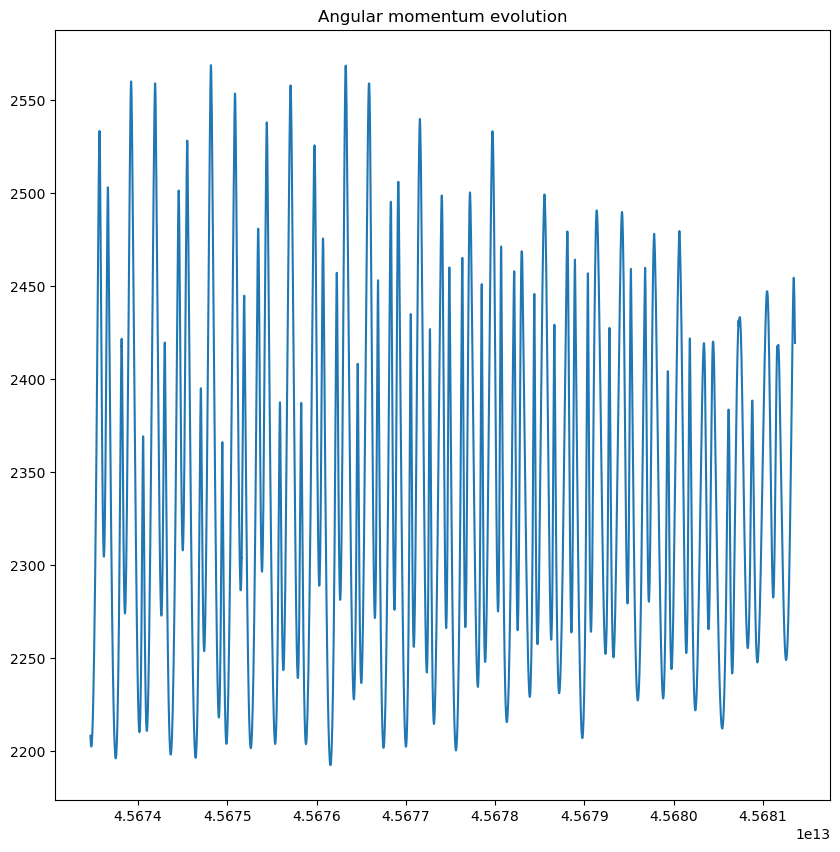

In [ ]:
"Create diagnostic velocity plots"
print(temp_tab.columns)
time_rem = temp_tab["evo_time_rem"]
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
ax.set_title("Angular momentum evolution")
ax.plot(time_rem,ang_mom)
plt.show()
plt.close(fig)


45681357613009.92 100    4.568124e+13
101    4.568124e+13
102    4.568123e+13
Name: evo_time_rem, dtype: float64
ID                9480S88668358866835Z0006N0
x                                   9.836449
y                                   0.001265
z                                   1.916195
vx                                 49.105777
vy                                198.304901
vz                                -130.75217
evo_time_rem           45681357613009.921875
kick_flag                                0.0
e                                       -1.0
Binary_ID               S88668358866835Z0006
Particle_ID                    8796510079480
Birth_Snapshot                            79
Birth_Time                0.1265287399226782
Unique_ID               S88668358866835Z0006
Age 1 [yr]                        41202250.0
Kick 1 [km/s]                      35.521367
Age 2 [yr]                        29882020.0
Kick 2 [km/s]                      95.439518
Name: 0, dtype: object          

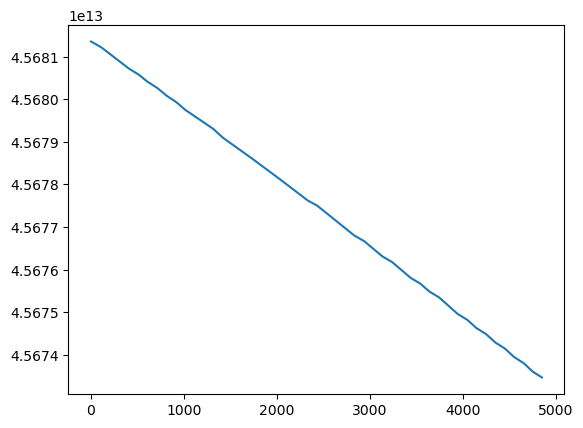

In [ ]:
#print(temp_tab)
#print(time_rem)
print(time_rem[0],time_rem[100:103])
print(temp_tab.iloc[0],temp_tab.iloc[100:103])#,time_rem[100:103])
#plt.plot(np.arccos(ang_mom_vec.T[2]/ang_mom))
plt.plot(temp_tab["evo_time_rem"].values)
#temp_tab[90:110]

# Birth Distribution

In [ ]:
from scipy.ndimage import gaussian_filter
"Initialise stellar particles - Example 120"
birth_snap = initial_snapshot

birth_part = pd.read_csv("../../stellar_particles/stellar_particles_{}.csv".format(birth_snap))
birth_part = birth_part.dropna()


10741     -24.438629
11081     -19.384802
14216     -18.919333
17740      -5.720409
17741      -6.320447
             ...    
9355202     2.672791
9355203     2.544153
9355204     1.677644
9355205     2.060075
9355206     1.417539
Name: x, Length: 6122506, dtype: float64 10741     -15.304193
11081      14.859963
14216      -2.527518
17740     -25.888683
17741     -26.690693
             ...    
9355202    -0.894682
9355203    -3.840646
9355204     0.832455
9355205    -1.576773
9355206     0.937905
Name: y, Length: 6122506, dtype: float64
29.99798583984375
counts_seed stats: 1.0 4.0 758
1.3533905675187075
[0.00023592360039253565, 0.0007925059655564087]
0.0


C:\Users\u77526sm\AppData\Local\Temp\ipykernel_11040\816085217.py:54: RuntimeWarning: divide by zero encountered in log10
  img=  ax.pcolormesh(xbins, ybins, np.log10(counts).T, cmap='coolwarm',vmin=1.5,vmax=3.5)


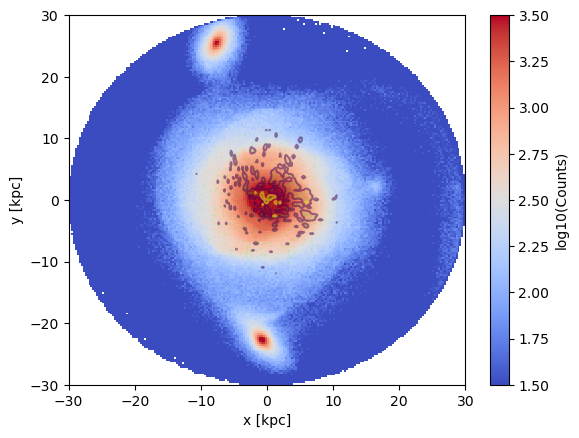

In [ ]:
#print(birth_part)


"Sort particles"
x= birth_part.x
y= birth_part.y
z = birth_part.z
r = np.sqrt(x**2+y**2)
cond = r<30
birth_part_temp = birth_part.loc[cond]
x= birth_part_temp.x
y= birth_part_temp.y
z = birth_part_temp.z

"Load seeded binaries"
seed_tab = store["run_orbit/{}".format(birth_snap)]
seed_tab.drop_duplicates(["ID"],keep="first",inplace=True)
x_seed = seed_tab["x"].astype(float)
y_seed = seed_tab["y"].astype(float)
z_seed  =seed_tab["z"].astype(float)
r_seed = np.sqrt(x_seed**2+y_seed**2)
centralise=(0,0,0)
x_seed= seed_tab.x.astype(float)+centralise[0]
y_seed= seed_tab.y.astype(float)+centralise[1]
z_seed= seed_tab.z.astype(float)+centralise[2]





print(x,y)
#print(np.log10(x),np.log10(y))
buffer= 0.00001
coords = np.asarray([x,y,z])
counts, xbins, ybins = np.histogram2d(x,y, bins=200,range=((x.min(),x.max()),(y.min(),y.max())))
dx= (xbins[1]-xbins[0])/2.
dy = (ybins[1]-ybins[0])/2.
print(xbins.max())

#counts_seed, xbins_seed, ybins_seed = np.histogram2d(x_seed,y_seed, bins=200,range=((x.min(),x.max()),(y.min(),y.max())))
counts_seed, xbins_seed, ybins_seed = np.histogram2d(np.log10(x_seed+np.abs(1.1*x_seed.min())),np.log10(y_seed+np.abs(1.1*y_seed.min())), bins=200)
counts_seed_smooth = gaussian_filter(counts_seed, sigma=1.0)
print("counts_seed stats:", np.min(counts_seed[counts_seed>0]), np.max(counts_seed), np.sum(counts_seed>0))
dx_seed= (xbins_seed[1]-xbins_seed[0])/2.
dy_seed = (ybins_seed[1]-ybins_seed[0])/2.
print(xbins_seed.max())

fig = plt.figure(1)
ax = fig.add_subplot(111)
img=  ax.pcolormesh(xbins, ybins, np.log10(counts).T, cmap='coolwarm',vmin=1.5,vmax=3.5)
ax.scatter(x_seed,y_seed,s=0.3,color="lime",alpha=0.1)
fig.colorbar(img, ax=ax, label='log10(Counts)')
#ax.scatter(new_data['x'],new_data['y'],s=0.005,color='green',alpha=0.01)
#levels =[np.quantile(counts_seed,i) for i in [0.01,0.1,0.25,0.5,0.75,0.9,0.99]]
#levels =[np.quantile(counts_seed[counts_seed>0].T,i) for i in [0.5,0.99]]
max_count = counts_seed_smooth.max()
levels = [0.1*max_count, 0.5*max_count, 0.9*max_count]
levels_birth = levels


vals = counts_seed_smooth.ravel()

vals /=vals.sum()

sorted_vals = np.sort(vals) #Sort values and take the inverse
cumsum_vals = np.cumsum(sorted_vals) #Sort values and then find the cumulative summation

"Thresholds"
vals_1 = sorted_vals[cumsum_vals>=0.01][0]
vals_50 = sorted_vals[cumsum_vals>=0.50][0]

vals_68 = sorted_vals[cumsum_vals>=0.68][0]
vals_95 = sorted_vals[cumsum_vals>=0.95][0]

levels = [vals_50,vals_95]


print(levels)
#ax.contourf(xbins_seed[1:]-dx_seed,ybins_seed[1:]-dy_seed,counts_seed,levels,alpha=0.2)
print(counts.min())
#cs= ax.contour(xbins_seed[1:],ybins_seed[1:],counts_seed.T,levels,alpha=0.5)
#cs = ax.contour(xbins_seed[1:], ybins_seed[1:], counts_seed_smooth.T, levels, alpha=0.5)
cs = ax.contour(10**(xbins_seed[1:]-dx_seed)-np.abs(1.1*x_seed.min()), 10**(ybins_seed[1:]-dy_seed)-np.abs(1.1*y_seed.min()), counts_seed_smooth.T, levels, alpha=0.5)
#ax.clabel(cs,cs.levels,inline=True,fontsize=10)
ax.set_xlim((-30,30))
ax.set_ylim((-30,30))
ax.set_xlabel("x [kpc]")
ax.set_ylabel("y [kpc]")
plt.savefig("birth_distribution_{}.png".format(birth_snap))

plt.show()
#plt.close()


# Current Epoch


In [ ]:
"Initialise stellar particles - Example 127"
final_snap = latest_snapshot

final_part = pd.read_csv("../../stellar_particles/stellar_particles_{}.csv".format(final_snap))
final_part = final_part.dropna()


[-5.31137943  3.29966712 -1.25437093 ... -1.98891449 -0.64201742
  1.4125191 ] [ 1.06152308 -8.9534359   9.55059052 ... -2.13566589 -1.39742005
  2.53233528]
29.9859561920166
1.4900755967794097
[0.0005090322673000639, 0.0019351070433011274]
0.0


C:\Users\u77526sm\AppData\Local\Temp\ipykernel_11040\2773451731.py:18: RuntimeWarning: divide by zero encountered in log10
  img=  ax.pcolormesh(xbins, ybins, np.log10(counts).T, cmap='coolwarm',vmin=1.5,vmax=3.5)


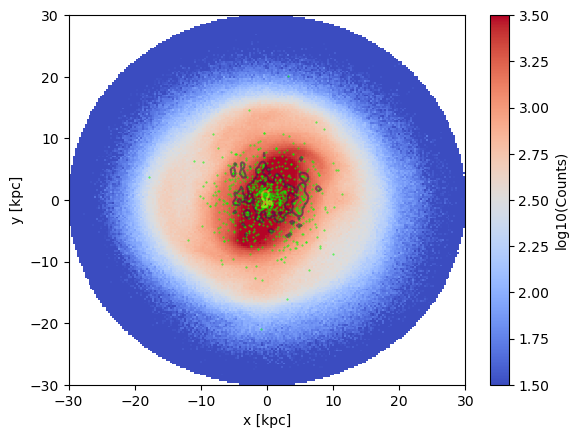

In [ ]:


print(x,y)
#print(np.log10(x),np.log10(y))
buffer= 0.00001
coords = np.asarray([x,y,z])
counts, xbins, ybins = np.histogram2d(x,y, bins=200,range=((x.min(),x.max()),(y.min(),y.max())))
dx= (xbins[1]-xbins[0])/2.
dy = (ybins[1]-ybins[0])/2.
print(xbins.max())

counts_seed, xbins_seed, ybins_seed = np.histogram2d(np.log10(x_seed+np.abs(1.1*x_seed.min())),np.log10(y_seed+np.abs(1.1*y_seed.min())), bins=200)
counts_seed_smooth = gaussian_filter(counts_seed, sigma=1.0)
dx_seed= (xbins_seed[1]-xbins_seed[0])/2.
dy_seed = (ybins_seed[1]-ybins_seed[0])/2.
print(xbins_seed.max())

fig = plt.figure(1)
ax = fig.add_subplot(111)
img=  ax.pcolormesh(xbins, ybins, np.log10(counts).T, cmap='coolwarm',vmin=1.5,vmax=3.5)
fig.colorbar(img, ax=ax, label='log10(Counts)')
ax.scatter(x_seed,y_seed,s=0.4,color='lime',marker='*',alpha=0.5)
max_count = counts_seed_smooth.max()
R_seed = np.sqrt(xbins_seed**2+ybins_seed**2)
levels = [np.quantile(R_seed,0.01),np.quantile(R_seed,0.5),np.quantile(R_seed,0.90)]
vals = counts_seed_smooth.ravel()
vals /=vals.sum()

sorted_vals = np.sort(vals) #Sort values and take the inverse
cumsum_vals = np.cumsum(sorted_vals) #Sort values and then find the cumulative summation

"Thresholds"
vals_25 = sorted_vals[cumsum_vals>=0.25][0]
vals_50 = sorted_vals[cumsum_vals>=0.50][0]

vals_68 = sorted_vals[cumsum_vals>=0.68][0]
vals_95 = sorted_vals[cumsum_vals>=0.95][0]

levels = [vals_50,vals_95]

cs = ax.contour(10**(xbins_seed[1:]-dx_seed)-np.abs(1.1*x_seed.min()), 10**(ybins_seed[1:]-dy_seed)-np.abs(1.1*y_seed.min()), counts_seed_smooth.T, levels, alpha=0.5)
#ax.clabel(cs,cs.levels,inline=True,fontsize=10)
ax.set_xlim((-30,30))
ax.set_ylim((-30,30))
ax.set_xlabel("x [kpc]")
ax.set_ylabel("y [kpc]")
plt.savefig("final_distribution_{}.png".format(birth_snap))

plt.show()
#plt.close()

Exceptionally Far Binaries: 0.0
Quantiles [0.95]: 9.777317246967195
Quantiles [0.68]: 6.06280817468902
Quantiles [0.5]: 4.681135070814671


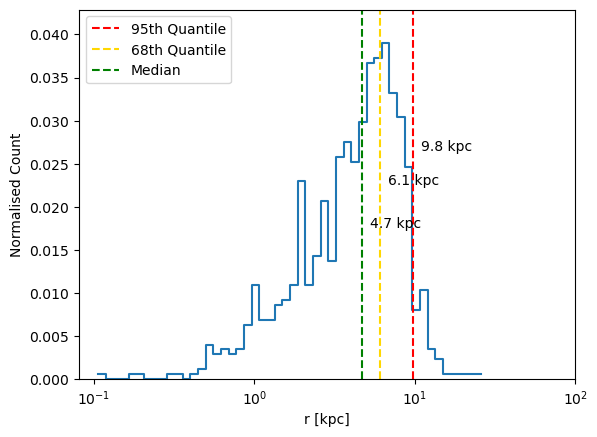

In [ ]:
"Radial offset"

r_seed_3d = np.sqrt(x_seed**2+y_seed**2+z_seed**2)
count,bin = np.histogram(np.log10(r_seed_3d),bins=50)
print("Exceptionally Far Binaries: {}".format(len(r_seed_3d[r_seed_3d>30])*100/len(r_seed_3d)))
print("Quantiles [0.95]: {}".format(np.quantile(r_seed_3d,0.95)))
print("Quantiles [0.68]: {}".format(np.quantile(r_seed_3d,0.68)))
print("Quantiles [0.5]: {}".format(np.quantile(r_seed_3d,0.5)))

dx = bin[1]-bin[0]

new_count = np.asarray(list(zip(count,count))).flatten()
new_count = new_count/np.sum(new_count) #Normalise count
new_bins = np.asarray(list(zip(bin[:-1],bin[1:]))).flatten()

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(new_bins,new_count)
ax.vlines(np.log10(np.quantile(r_seed_3d,0.95)),0,1,color='red',linestyles='--',label='95th Quantile')
ax.vlines(np.log10(np.quantile(r_seed_3d,0.68)),0,1,color='gold',linestyles='--',label='68th Quantile')
ax.vlines(np.log10(np.quantile(r_seed_3d,0.50)),0,1,color='green',linestyles='--',label='Median')
ax.text(np.log10(np.quantile(r_seed_3d,0.50))+0.05,0.45*new_count.max(),"{:.1f} kpc".format(np.quantile(r_seed_3d,0.50)))
ax.text(np.log10(np.quantile(r_seed_3d,0.68))+0.05,0.58*new_count.max(),"{:.1f} kpc".format(np.quantile(r_seed_3d,0.68)))
ax.text(np.log10(np.quantile(r_seed_3d,0.95))+0.05,0.68*new_count.max(),"{:.1f} kpc".format(np.quantile(r_seed_3d,0.95)))
tick_labels =[-1,0,1,2]
ax.set_xlabel("r [kpc]")#3D Radial Displacement [kpc]")
ax.set_ylabel("Normalised Count")
ax.set_xticks(tick_labels)
ax.set_xticklabels([r'$10^{{{:.0f}}}$'.format(tick) for tick in tick_labels])
ax.set_ylim((0,1.1*new_count.max()))
ax.legend(loc="upper left")
plt.savefig("r_distribution.png")


                             ID                    x                     y  \
0    9480S88668358866835Z0006N0  -5.4097375297516095     7.733038731692642   
1    8551S63560346356034Z0006N0    7.445184157526238    -4.341350066770672   
2    3430S81877358187735Z0006N0    2.941477679204596    -16.06079471084937   
3    1114S87825468782546Z0006N0   -1.394997770606436      8.21997746758311   
4    8797S50470075047007Z0008N0   -5.290571917603531    3.4515336207400678   
..                          ...                  ...                   ...   
819   1268S14880091488009Z004N0   0.6465004839299521  -0.38162988436354034   
820     2976S419638419638Z004N0   0.1961758862886084    -2.324596192441543   
821   1808S11162621116262Z004N0  -0.5767608772036981    0.7492729482841576   
822     5891S773657773657Z004N0  -2.6622833965425983   -0.2219973670533861   
823   5862S17061961706196Z004N0  -0.9447139049077669    1.6297728209752502   

                       z                   vx                  

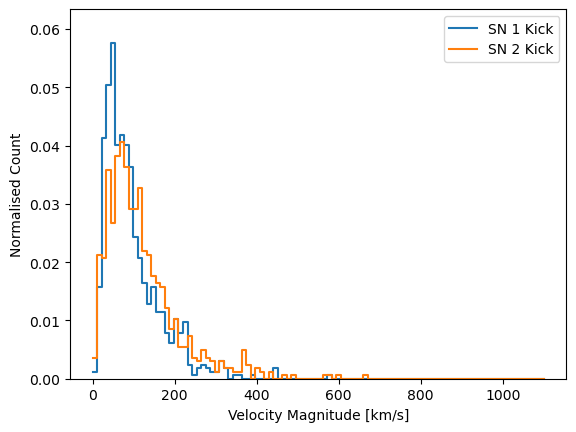

In [ ]:
"Kick Distribution"
#print(seed_tab)
seed_tab_temp = seed_tab.merge(joint_tab,how='inner',left_on='ID',right_on="ID")
print(seed_tab_temp)
sn_kick_1 = seed_tab_temp["Kick 1 [km/s]"]
sn_kick_2 = seed_tab_temp["Kick 2 [km/s]"]

fig = plt.figure()
ax = fig.add_subplot(111)

for i in [1,2]:

    count,bin = np.histogram(seed_tab_temp["Kick {} [km/s]".format(i)],bins=100,range=(0,1100))
    dx = bin[1]-bin[0]
    new_count = np.asarray(list(zip(count,count))).flatten()
    new_count = new_count/np.sum(new_count) #Normalise count
    new_bins = np.asarray(list(zip(bin[:-1],bin[1:]))).flatten()
    ax.plot(new_bins,new_count,label = 'SN {} Kick'.format(i))
    if i==1:
        ax.set_ylim((0,1.1*new_count.max()))
ax.set_xlabel("Velocity Magnitude [km/s]")
ax.set_ylabel("Normalised Count")

ax.legend(loc="best")
plt.savefig("kick_distribution.png")


                             ID                    x                     y  \
0    9480S88668358866835Z0006N0  -5.4097375297516095     7.733038731692642   
1    8551S63560346356034Z0006N0    7.445184157526238    -4.341350066770672   
2    3430S81877358187735Z0006N0    2.941477679204596    -16.06079471084937   
3    1114S87825468782546Z0006N0   -1.394997770606436      8.21997746758311   
4    8797S50470075047007Z0008N0   -5.290571917603531    3.4515336207400678   
..                          ...                  ...                   ...   
819   1268S14880091488009Z004N0   0.6465004839299521  -0.38162988436354034   
820     2976S419638419638Z004N0   0.1961758862886084    -2.324596192441543   
821   1808S11162621116262Z004N0  -0.5767608772036981    0.7492729482841576   
822     5891S773657773657Z004N0  -2.6622833965425983   -0.2219973670533861   
823   5862S17061961706196Z004N0  -0.9447139049077669    1.6297728209752502   

                       z                   vx                  

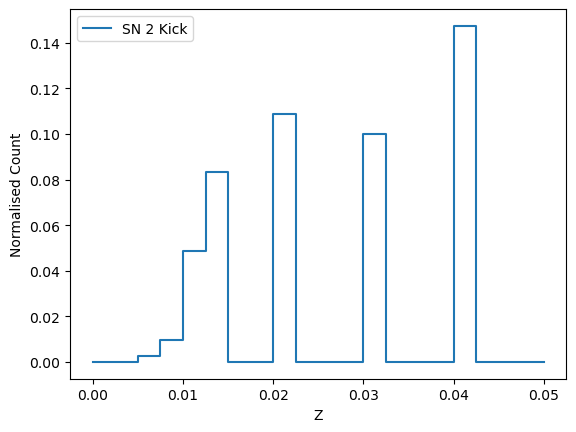

In [ ]:
"Kick Distribution"
seed_tab_temp = seed_tab.merge(joint_tab,how='inner',left_on='ID',right_on="ID")
print(seed_tab_temp)
print(seed_tab_temp.Binary_ID)
Z = np.asarray([float("0."+Z_temp.split("Z")[1][1:]) for Z_temp in seed_tab_temp.Binary_ID])
print(np.unique(Z))
fig = plt.figure()
ax = fig.add_subplot(111)


count,bin = np.histogram(Z,bins=20,range=(0,0.05))
dx = bin[1]-bin[0]
new_count = np.asarray(list(zip(count,count))).flatten()
new_count = new_count/np.sum(new_count) #Normalise count
new_bins = np.asarray(list(zip(bin[:-1],bin[1:]))).flatten()
ax.plot(new_bins,new_count,label = 'SN {} Kick'.format(i))
if i==1:
    ax.set_ylim((0,1.1*new_count.max()))
ax.set_xlabel("Z")
ax.set_ylabel("Normalised Count")

ax.legend(loc="best")
plt.savefig("kick_distribution.png")
